# 03 — Timescale-resolved prediction with calibrated uncertainty

Boiling physics differs by timescale (slow convection vs fast bubble dynamics), and part of the heat flux is genuinely random. `BandwiseModalModel` therefore:

1. **partitions** temperature and heat flux into frequency bands,
2. learns a **separate Model-C mapping per band**, and
3. (with `n_members > 1`) wraps each band in a **deep ensemble**, reporting a mean *and* a calibrated uncertainty interval that combines model disagreement (epistemic) with irreducible scatter (aleatoric).

In [1]:
import icarus as tf

In [2]:
import numpy as np

def make_boiling_like_data(ny=24, nx=30, nt=1500, dt=1e-3, seed=0):
    """Synthetic dataset that mimics a boiling IR recording:
    a slow large-scale mode + a localized 'nucleation site' pulsing at 40 Hz,
    with heat flux linearly coupled to temperature + irreducible noise."""
    rng = np.random.default_rng(seed)
    yy, xx = np.meshgrid(np.linspace(0, 1, nx), np.linspace(0, 1, ny))
    t = np.arange(nt) * dt

    slow_pattern = np.sin(np.pi * yy) * np.cos(np.pi * xx)
    slow = slow_pattern[:, :, None] * np.sin(2 * np.pi * 5 * t)

    site = np.exp(-(((yy - 0.7) ** 2 + (xx - 0.6) ** 2) / 0.01))
    site_pulse = site[:, :, None] * np.sin(2 * np.pi * 40 * t)

    T = 420.0 + 3.0 * slow + 1.5 * site_pulse         + 0.05 * rng.standard_normal((ny, nx, nt))
    q = 3.0e5 - 1.2e4 * (3.0 * slow) + 0.9e4 * (1.5 * site_pulse)         + 2.0e3 * rng.standard_normal((ny, nx, nt))
    return T, q, dt

T, q, dt = make_boiling_like_data()
print("T", T.shape, "| q", q.shape, "| dt", dt, "s")


T (24, 30, 1500) | q (24, 30, 1500) | dt 0.001 s


## 1. Fit — one ensemble per frequency band

Edges can be manual (`edges=[20]` → below/above 20 Hz) or data-driven (`edges="auto"`).

In [3]:
model = tf.BandwiseModalModel(
    edges=[20], n_pod_modes=3, n_members=3,
    model_kwargs={"hidden_layer_sizes": (32,), "max_iter": 250})
model.fit(T, q, dt=dt, spatial_crop=2)
report = model.evaluate()   # total + per-band R²

[total]  R² = 0.9749  RMSE = 2,000 W/m²  MAE = 1,596 W/m²
[0-20 Hz]  R² = 0.9990  RMSE = 398 W/m²  MAE = 317 W/m²
[20+ Hz]  R² = 0.3301  RMSE = 1,960 W/m²  MAE = 1,564 W/m²


## 2. Predict with a 90 % interval

In [4]:
T_c = T[2:-2, 2:-2, :]      # same crop the model trained on
q_c = q[2:-2, 2:-2, :]
mean, lower, upper = model.predict_interval(T_c, coverage=0.9)
cal = tf.interval_metrics(q_c, lower, upper)
print(f"nominal 90% -> actual coverage {cal['coverage']:.3f}, "
      f"mean width {cal['mean_width']:,.0f} W/m^2")

nominal 90% -> actual coverage 0.900, mean width 6,582 W/m^2


Coverage close to 0.90 means the uncertainty is **honest**: the band contains the truth as often as it claims to.

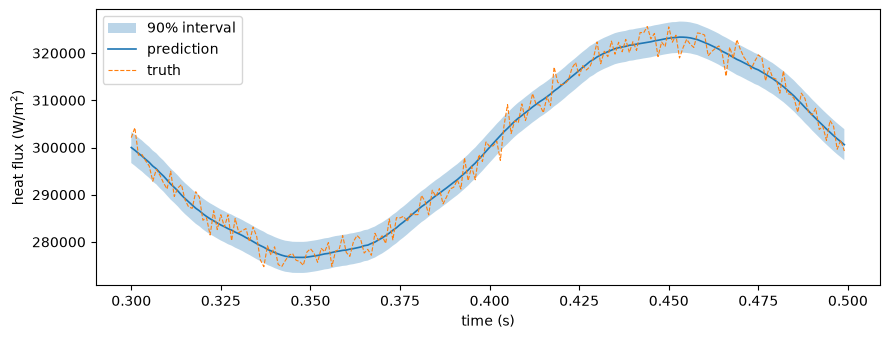

In [5]:
import numpy as np, matplotlib.pyplot as plt
py, px = 16, 18            # a pixel inside the pulsing site
sl = slice(300, 500)
t_ax = np.arange(q_c.shape[2])[sl] * dt
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.fill_between(t_ax, lower[py, px, sl], upper[py, px, sl],
                alpha=0.3, label="90% interval")
ax.plot(t_ax, mean[py, px, sl], lw=1.2, label="prediction")
ax.plot(t_ax, q_c[py, px, sl], lw=0.8, ls="--", label="truth")
ax.set_xlabel("time (s)"); ax.set_ylabel("heat flux (W/m$^2$)")
ax.legend(); plt.tight_layout()

The interval widens where the signal is harder to predict — that is the point: an honest model tells you *where* it doesn't know.

With real data, simply swap the synthetic block for
`T, _ = tf.load_field("run.mat", "temp")` and `q, dt = tf.load_field("run.mat", "heatflux")`.

---
**Reference:** the per-band uncertainty uses deep ensembles (Lakshminarayanan, B., Pritzel, A. & Blundell, C. (2017), "Simple and scalable predictive uncertainty estimation using deep ensembles", *NeurIPS 30*), combined with an aleatoric term estimated from training residuals.